<a href="https://colab.research.google.com/github/naurasafina/python-google-colab-projek/blob/main/Prediksi_Adjusted_Close_MLPRegressor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IMPORT LIBRARY

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

LOAD DATA

In [ ]:
import pandas as pd

df = pd.read_excel('NaurahSafina_Data_TeknikPeramalan.xlsx', header=None)

df_headers = df.iloc[0]
df.columns = df_headers.tolist()
df = df[1:].reset_index(drop=True)

df = df.dropna(subset=['Date', 'Adj Close'])

df['Adj Close'] = pd.to_numeric(df['Adj Close'], errors='coerce')
df = df.dropna(subset=['Adj Close'])

df['Date'] = pd.to_datetime(df['Date'], format='mixed', dayfirst=True)

df = df.sort_values('Date').reset_index(drop=True)

df = df[['Date', 'Adj Close']]
df = df.set_index('Date')

print(df.head())

            Adj Close
Date                 
2018-01-08  338380005
2018-01-10  381429993
2018-01-11  317380005
2018-02-07  398179993
2018-02-08  344500000


IDENTIFIKASI POLA

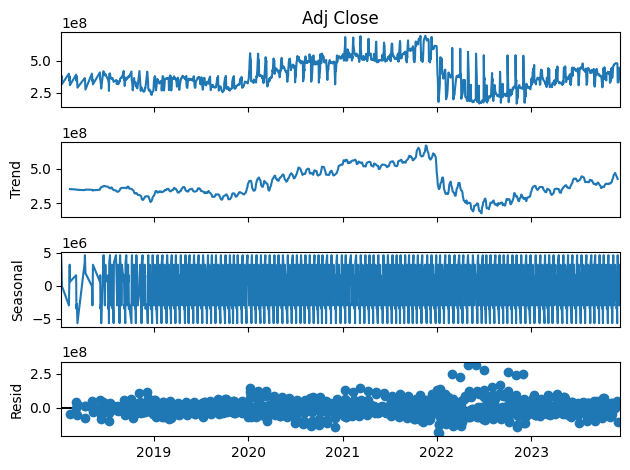

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

data_for_decompose = df['Adj Close']

if len(data_for_decompose) >= 24:
    result = seasonal_decompose(data_for_decompose, model='additive', period=12)

    result.plot()

TRANSFORMASI LOG

In [ ]:
data_raw = df['Adj Close']
data_log = np.log1p(data_raw).values.reshape(-1, 1)

WINDOWING

In [ ]:
def create_sequences(data, window_size):
    X = []
    y = []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)

scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data_log)

window_size = 60
X, y = create_sequences(data_scaled, window_size)

TRAIN-TEST SPLIT

In [ ]:
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

GRAFIK HASIL SPLIT DATA

Total Data      : 1375
Data Training   : 1052 (Dari 2018-08 sampai 2022-11)
Data Testing    : 263  (Dari 2022-11 sampai 2023-12)


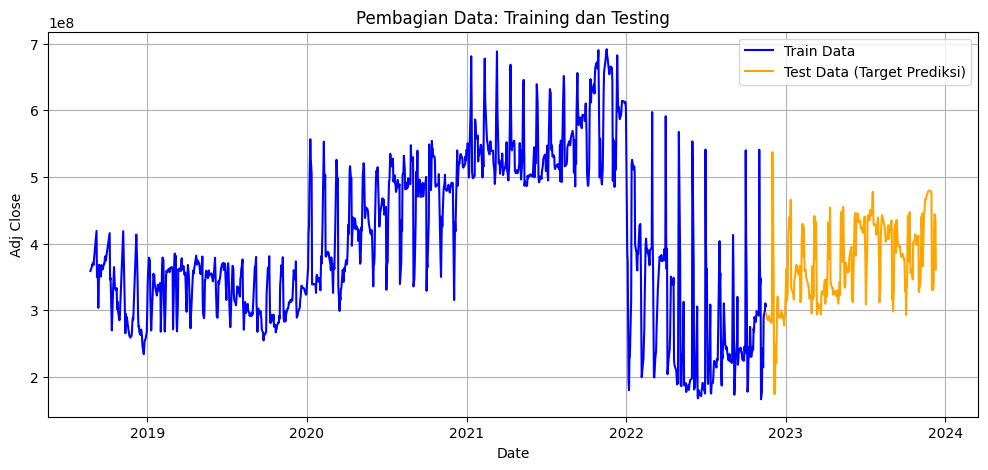

In [ ]:
total_target_data_points = len(df) - window_size

train_data_end_index = window_size + train_size

train_data = df.iloc[window_size : train_data_end_index]
test_data = df.iloc[train_data_end_index :]

print(f"Total Data      : {len(df)}")
print(f"Data Training   : {len(train_data)} (Dari {train_data.index.min().strftime('%Y-%m')} sampai {train_data.index.max().strftime('%Y-%m')})")
print(f"Data Testing    : {len(test_data)}  (Dari {test_data.index.min().strftime('%Y-%m')} sampai {test_data.index.max().strftime('%Y-%m')})")

plt.figure(figsize=(12, 5))
plt.plot(train_data.index, train_data['Adj Close'], label='Train Data', color='blue')
plt.plot(test_data.index, test_data['Adj Close'], label='Test Data (Target Prediksi)', color='orange')
plt.title('Pembagian Data: Training dan Testing')
plt.xlabel('Date')
plt.ylabel('Adj Close')
plt.legend()
plt.grid(True)
plt.show()

MODEL ARIMA

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA

arima_order = (1, 1, 1)

history = list(y_train.flatten())
y_test_flat = y_test.flatten()
y_pred_arima = []

for t in range(len(y_test_flat)):
    model = ARIMA(history, order=arima_order)
    model_fitted = model.fit()

    output = model_fitted.forecast(steps=1)
    yhat = output[0]
    y_pred_arima.append(yhat)

    obs = y_test_flat[t]
    history.append(obs)

y_pred_arima = np.array(y_pred_arima)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


EVALUASI MODEL

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test_flat, y_pred_arima)

# Menghitung Mean Squared Error (MSE)
mse = mean_squared_error(y_test_flat, y_pred_arima)

rmse = np.sqrt(mse)

mape = np.mean(np.abs((y_test_flat - y_pred_arima) / (y_test_flat + 1e-10))) * 100

print(" "*30)
print("HASIL EVALUASI MODEL ARIMA")
print(" "*30)
print(f"Mean Absolute Error (MAE)      : {mae:.4f}")
print(f"Mean Squared Error (MSE)       : {mse:.4f}")
print(f"Root Mean Squared Error (RMSE) : {rmse:.4f}")
print(f"Mean Absolute Percentage Error : {mape:.2f}%")
print(" "*30)

                              
HASIL EVALUASI MODEL ARIMA
                              
Mean Absolute Error (MAE)      : 0.0503
Mean Squared Error (MSE)       : 0.0062
Root Mean Squared Error (RMSE) : 0.0789
Mean Absolute Percentage Error : 15.32%
                              


perbandingan prediksi dan aktual

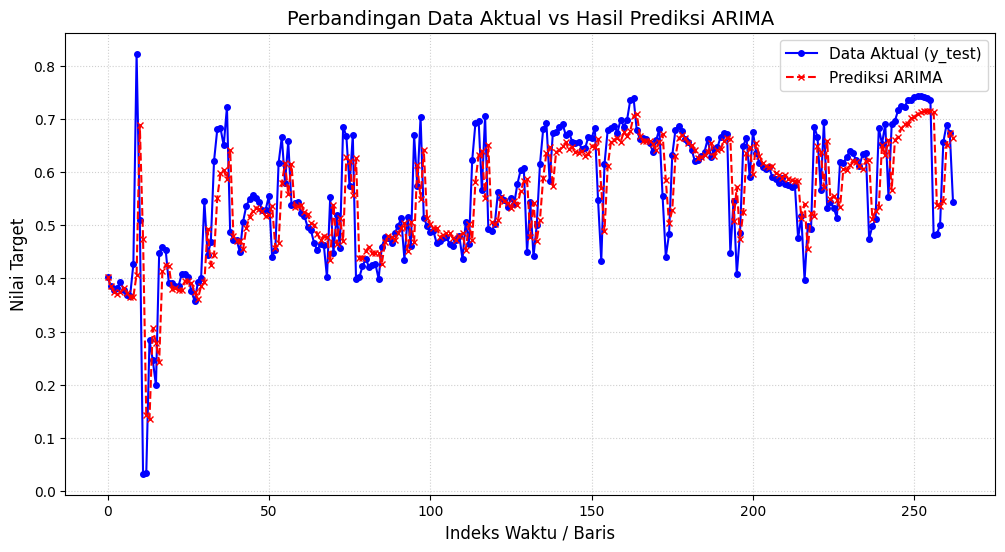

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(y_test_flat, label='Data Aktual (y_test)', color='blue', marker='o', markersize=4)
plt.plot(y_pred_arima, label='Prediksi ARIMA', color='red', linestyle='--', marker='x', markersize=4)

plt.title('Perbandingan Data Aktual vs Hasil Prediksi ARIMA', fontsize=14)
plt.xlabel('Indeks Waktu / Baris', fontsize=12)
plt.ylabel('Nilai Target', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()